# Table of Contents

- [Dataset Acquisition](#dataset-acquisition)
- [Preprocessing](#preprocessing)
- [Classification](#classification)
  - [Common setup](#common-setup)
  - [Logistic Regression](#logistic-regression)
  - [Naive Bayes](#naive-bayes)
  - [Decision Tree](#decision-tree)
  - [Random Forest](#random-forest)
  - [AdaBoost](#adaboost)
  - [Gradient Boost](#gradient-boost)
- [Comparison](#comparison)
  - [Performance stability across folds](#performance-stability-across-folds)
  - [Final model choice](#final-model-choice)
  - [Roc plot](#roc-plot)
  - [Wilcoxon tests](#wilcoxon-tests)
  - [Normalized Confusion Matrix of chosen model](#normalized-confusion-matrix-of-chosen-model)
- [Saving / Loading](#saving--loading)
- [Final Tuning and Training](#final-tuning-and-training)
- [XAI](#xai)
  - [Error Analysis: what drives False Negatives and False Positives](#error-analysis-what-drives-false-negatives-and-false-positives)
  - [What drives a FALSE NEGATIVE (a missed default)?](#what-drives-a-false-negative-a-missed-default)
  - [What drives a FALSE POSITIVE (a false alarm)?](#what-drives-a-false-positive-a-false-alarm)
  - [Visual comparison on all four TP/TN/FP/FN](#visual-comparison-on-all-four-tptnfpfn)


In [4]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
import sklearn

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.model_selection import StratifiedKFold, GridSearchCV, RandomizedSearchCV
from sklearn.metrics import (
    roc_auc_score, f1_score, precision_score, recall_score,
    balanced_accuracy_score, confusion_matrix, roc_curve, auc, 
    ConfusionMatrixDisplay
)
from sklearn.linear_model import LogisticRegression
from scipy.stats import loguniform

from sklearn.naive_bayes import GaussianNB
from sklearn.preprocessing import FunctionTransformer

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.ensemble import GradientBoostingClassifier

import joblib

from scipy.stats import wilcoxon

import scipy.sparse as sp
import shap
from lime import lime_tabular
from IPython.display import display, HTML 

import re

SEED = 42

# Dataset Acquisition

Dataset contains 34 features and over 148.000 records. The preview shows target feature "Status" (1 = default, 0 = not default) and a mixture of numeric features (es. loan_amount, income, Credit_Score) and categorical/ordinal/nominal ones (es. loan_type, Gender, Region). The obvious presence of numerous NaN values (es. LTV, dtir1) confirms that an accurate preprocessing phase is needed.

In [24]:
github_csv_url = 'https://raw.githubusercontent.com/marcolari06-maker/loan-default-prediction/refs/heads/main/dataset.csv'

try:
    df_git = pd.read_csv(github_csv_url)
    print("Dataset loaded from github repo loan-default-prediction")
    display(df_git.head())
    print(df_git.shape[0])
except Exception as e:
    print(f"Error during loading from github: {e}")


Dataset loaded from github repo loan-default-prediction


,ID,year,loan_limit,Gender,approv_in_adv,loan_type,loan_purpose,Credit_Worthiness,open_credit,business_or_commercial,...,credit_type,Credit_Score,co-applicant_credit_type,age,submission_of_application,LTV,Region,Security_Type,Status,dtir1
0,24890,2019,cf,Sex Not Available,nopre,type1,p1,l1,nopc,nob/c,...,EXP,758,CIB,25-34,to_inst,98.728814,south,direct,1,45.0
1,24891,2019,cf,Male,nopre,type2,p1,l1,nopc,b/c,...,EQUI,552,EXP,55-64,to_inst,NaN,North,direct,1,NaN
2,24892,2019,cf,Male,pre,type1,p1,l1,nopc,nob/c,...,EXP,834,CIB,35-44,to_inst,80.019685,south,direct,0,46.0
3,24893,2019,cf,Male,nopre,type1,p4,l1,nopc,nob/c,...,EXP,587,CIB,45-54,not_inst,69.376900,North,direct,0,42.0
4,24894,2019,cf,Joint,pre,type1,p1,l1,nopc,nob/c,...,CRIF,602,EXP,25-34,not_inst,91.886544,North,direct,0,39.0


148670


In [ ]:
target_col = "Status"
id_col = "ID" if "ID" in df_git.columns else None

print("SHAPE:", df_git.shape)
print("\nTARGET distribution:")
print(df_git[target_col].value_counts(dropna=False))

print("\nEXACT DUPLICATE ROWS:", df_git.duplicated().sum())

if id_col is not None:
    print("\nID check:")
    print("Unique IDs:", df_git[id_col].nunique(dropna=False))
    print("Repeated ID values:", (df_git[id_col].value_counts(dropna=False) > 1).sum())
    print("Rows with repeated ID:", df_git[id_col].duplicated().sum())

    #verifies that ids are unique
    id_target = df_git.groupby(id_col)[target_col].nunique(dropna=False)
    print("\nIDs with more than one target value:", (id_target > 1).sum())

SHAPE: (148670, 34)

TARGET distribution:
Status
0    112031
1     36639
Name: count, dtype: int64

EXACT DUPLICATE ROWS: 0

ID check:
Unique IDs: 148670
Repeated ID values: 0
Rows with repeated ID: 0

IDs with more than one target value: 0


# Preprocessing

In [ ]:
# REMOVAL OF FEATURES
df = df_git.copy()

columns_to_drop = ['Upfront_charges', 'rate_of_interest', 'Interest_rate_spread'
                  , 'property_value', 'LTV', 'ID', 'year', "credit_type"]

for col in columns_to_drop:
    if col in df.columns:
        df = df.drop(columns=[col])
        print(f"Column '{col}' dropped successfully.")
    else:
        print(f"Column '{col}' not found in the DataFrame. Skipping.")

# INSERTING UNKNOWN CLASS IN LOAN LIMIT
df['loan_limit'] = df['loan_limit'].fillna('Non_definito')
print("Loan limit after the operation")
print(df['loan_limit'].value_counts(dropna=False))

#REMOVAL OF RECORDS WITH NULL VALUES
interested_features = ['age', 'submission_of_application', 'loan_purpose', 'Neg_ammortization', 'term']
rows = df.shape[0]

for feat in interested_features:
    if feat in df.columns:
        df.dropna(subset=[feat], inplace=True)
        print(f"Rows dropped for {feat}: {rows - df.shape[0]}")
        rows = df.shape[0]
    else:
        print(f"Column '{feat}' not found. Skipping operation.")

# CHECK FOR DUPLICATE ROWS
duplicate_rows = df.duplicated().sum()

if duplicate_rows > 0:
    print(f"Number of duplicate rows found: {duplicate_rows}")
    # Optionally, display the duplicate rows
    # display(df[df.duplicated(keep=False)]) # keep=False shows all occurrences of duplicates
else:
    print("No duplicate rows found in the DataFrame.")

#REDUNDANCIES ADDRESSING
columns_to_remove = ['construction_type', 'Security_Type']

for col in columns_to_remove:
    if col in df.columns:
        df = df.drop(columns=[col])
        print(f"Column '{col}' removed successfully.")
    else:
        print(f"Column '{col}' not found in the DataFrame. Skipping.")

missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)

missing_df = pd.DataFrame({
    'Missing Values': missing,
    'Missing %': missing_pct
}).sort_values('Missing %', ascending=False)

# SHOWING ONLY FEATURES WITH MISSING VALUES
print(missing_df[missing_df['Missing Values'] > 0])

Column 'Upfront_charges' dropped successfully.
Column 'rate_of_interest' dropped successfully.
Column 'Interest_rate_spread' dropped successfully.
Column 'property_value' dropped successfully.
Column 'LTV' dropped successfully.
Column 'ID' dropped successfully.
Column 'year' dropped successfully.
Column 'credit_type' dropped successfully.
Loan limit after the operation
loan_limit
cf              135348
ncf               9978
Non_definito      3344
Name: count, dtype: int64
Rows dropped for age: 200
Rows dropped for submission_of_application: 0
Rows dropped for loan_purpose: 126
Rows dropped for Neg_ammortization: 121
Rows dropped for term: 41
Number of duplicate rows found: 12
Column 'construction_type' removed successfully.
Column 'Security_Type' removed successfully.
               Missing Values  Missing %
dtir1                   23883      16.12
income                   8949       6.04
approv_in_adv             908       0.61


# Classification

## Common setup

In [83]:
d = df.copy()
# --- feature / target ---
X = d.drop(columns=["Status"])
y = d["Status"]

num_features = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
cat_features = X.select_dtypes(include=["object"]).columns.tolist()

print("Numerical:", num_features)
print("Categorical:", cat_features)

# --- feature preprocesser ---
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),   #median imputation
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),  #mode imputation
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

preprocess = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, num_features),
        ("cat", categorical_transformer, cat_features),
    ]
)


Numerical: ['loan_amount', 'term', 'income', 'Credit_Score', 'dtir1']
Categorical: ['loan_limit', 'Gender', 'approv_in_adv', 'loan_type', 'loan_purpose', 'Credit_Worthiness', 'open_credit', 'business_or_commercial', 'Neg_ammortization', 'interest_only', 'lump_sum_payment', 'occupancy_type', 'Secured_by', 'total_units', 'co-applicant_credit_type', 'age', 'submission_of_application', 'Region']


In [84]:
outer_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=0)
inner_cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=SEED)

def build_local_grid(best_params, model_name):
    if model_name == "LogReg":
        c = best_params["clf__C"]
        return {
            "clf__C": np.logspace(np.log10(c/5), np.log10(c*5), 5),
            "clf__class_weight": [best_params["clf__class_weight"]],
            "clf__solver": [best_params["clf__solver"]],
            "clf__max_iter": [best_params["clf__max_iter"]],
            "clf__penalty": ["l2"]
        }

    if model_name == "DecTree":
        d = best_params["clf__max_depth"]
        m = best_params["clf__min_samples_leaf"]
        return {
            "clf__max_depth": [None] if d is None else sorted(list(set([max(1, d-2), d, d+2]))),
            "clf__min_samples_leaf": sorted(list(set([max(1, m-5), m, m+5]))),
            "clf__criterion": [best_params["clf__criterion"]],
            "clf__class_weight": [best_params["clf__class_weight"]]
        }

    if model_name == "RandFor":
        n = best_params["clf__n_estimators"]
        d = best_params["clf__max_depth"]
        m = best_params["clf__min_samples_leaf"]
        return {
            "clf__n_estimators": sorted(list(set([max(30, n-20), n, n+20]))),
            "clf__max_depth": [d] if d is None else sorted(list(set([max(2, d-2), d, d+2]))),
            "clf__min_samples_leaf": sorted(list(set([max(1, m-5), m, m+5]))),
            "clf__class_weight": [best_params["clf__class_weight"]],
            "clf__max_features": [best_params["clf__max_features"]]
        }

    if model_name == "AdaBoost":
        n = best_params["clf__n_estimators"]
        lr = best_params["clf__learning_rate"]
        return {
            "clf__n_estimators": sorted(list(set([max(20, n-20), n, n+20]))),
            "clf__learning_rate": np.logspace(np.log10(lr/3), np.log10(lr*3), 5)
        }

    if model_name == "NaiveBayes":
        return{
            "clf__var_smoothing": [1e-9, 1e-8, 1e-7, 1e-6, 1e-5]
        }

    if model_name == "GradBoost":
        n = best_params["clf__n_estimators"]
        m = best_params["clf__min_samples_leaf"]
        return {
            "clf__n_estimators": sorted(list(set([max(50, n-50), n, n+50]))),
            "clf__learning_rate": [best_params["clf__learning_rate"]],
            "clf__max_depth": [best_params["clf__max_depth"]],
            "clf__min_samples_leaf": sorted(list(set([max(1, m-5), m, m+5]))),
            "clf__subsample": [best_params["clf__subsample"]],
            "clf__max_features": [best_params["clf__max_features"]]
        }

    raise ValueError("Model not supported")

def nested_cv(pipeline, random_space, model_name, X, y, n_iter=20, scoring="roc_auc"):
    fold_rows = []
    oof_pred = np.zeros(len(y))
    oof_proba = np.zeros(len(y), dtype=float)

    for fold, (tr_idx, te_idx) in enumerate(outer_cv.split(X, y), start=1):
        X_tr, X_te = X.iloc[tr_idx], X.iloc[te_idx]
        y_tr, y_te = y.iloc[tr_idx], y.iloc[te_idx]

        rs = RandomizedSearchCV(
            pipeline,
            param_distributions=random_space,
            n_iter=n_iter,
            scoring=scoring,
            cv=inner_cv,
            n_jobs=1,
            random_state=SEED,
            refit=True
        )
        rs.fit(X_tr, y_tr)

        local_grid = build_local_grid(rs.best_params_, model_name)
        gs = GridSearchCV(
            pipeline,
            param_grid=local_grid,
            scoring=scoring,
            cv=inner_cv,
            n_jobs=1,
            refit=True
        )
        gs.fit(X_tr, y_tr)
        best_model = gs.best_estimator_
        
        y_pred = best_model.predict(X_te)
        y_score = best_model.predict_proba(X_te)[:, 1]

        oof_pred[te_idx] = y_pred
        oof_proba[te_idx] = y_score

        tn, fp, fn, tp = confusion_matrix(y_te, y_pred).ravel()
        fold_rows.append({
            "model": model_name,
            "fold": fold,
            "auc": roc_auc_score(y_te, y_score),
            "f1": f1_score(y_te, y_pred),
            "precision": precision_score(y_te, y_pred, zero_division=0),
            "recall": recall_score(y_te, y_pred, zero_division=0),
            "balanced_accuracy": balanced_accuracy_score(y_te, y_pred),
            "fpr": fp / (fp + tn) if (fp + tn) else 0.0,
            "fnr": fn / (fn + tp) if (fn + tp) else 0.0,
            "rs_best_params": rs.best_params_,
            "gs_best_params": gs.best_params_
        })

    fold_df = pd.DataFrame(fold_rows)
    summary = {
        "model": model_name,
        "auc_mean": fold_df["auc"].mean(),
        "auc_std": fold_df["auc"].std(),
        "f1_mean": fold_df["f1"].mean(),
        "f1_std": fold_df["f1"].std(),
        "precision_mean": fold_df["precision"].mean(),
        "precision_std": fold_df["precision"].std(),
        "recall_mean": fold_df["recall"].mean(),
        "recall_std": fold_df["recall"].std(),
        "balanced_accuracy_mean": fold_df["balanced_accuracy"].mean(),
        "balanced_accuracy_std": fold_df["balanced_accuracy"].std(),
        "fpr_mean": fold_df["fpr"].mean(),
        "fnr_mean": fold_df["fnr"].mean()
    }

    return {
        "summary": summary, 
        "folds": fold_df,
        "oof_pred": oof_pred, 
        "oof_proba": oof_proba
    }

In [85]:
def clean_params(params):
    return {
        k: v.item() if isinstance(v, np.generic) else v
        for k, v in params.items()
    }

def print_model_report(model_name, summary, folds, y_true, oof_pred, param_col="gs_best_params"):
    print("=" * 60)
    print(f"{model_name.upper()} - NESTED CV")
    print("=" * 60)

    print(f"AUC:      {summary['auc_mean']:.3f} ± {summary['auc_std']:.3f}")
    print(f"F1:       {summary['f1_mean']:.3f} ± {summary['f1_std']:.3f}")
    print(f"Precision:{summary['precision_mean']:.3f} ± {summary['precision_std']:.3f}")
    print(f"Recall:   {summary['recall_mean']:.3f} ± {summary['recall_std']:.3f}")
    print(f"BAcc:     {summary['balanced_accuracy_mean']:.3f} ± {summary['balanced_accuracy_std']:.3f}")
    print(f"FPR mean: {summary['fpr_mean']:.3f}")
    print(f"FNR mean: {summary['fnr_mean']:.3f}")


    print("\nFold metrics:")
    display(folds[[
        "fold", "auc", "f1", "precision", "recall",
        "balanced_accuracy", "fpr", "fnr"
    ]].round(3))

    # Single-fold parameters print
    # if param_col in folds.columns:
    #     param_strings = folds[param_col].astype(str)
    #     if param_strings.nunique() == 1:
    #         print("\nBest params:")
    #         print(clean_params(folds[param_col].iloc[0]))
    #     else:
    #         print("\nBest params per fold:")
    #         display(folds[["fold", param_col]])

    cm = confusion_matrix(y_true, oof_pred)
    tn, fp, fn, tp = cm.ravel()

    print("\nConfusion matrix OOF:")
    print(f"TN={tn} | FP={fp}")
    print(f"FN={fn} | TP={tp}")
    print(f"FPR={fp / (fp + tn):.3f} | FNR={fn / (fn + tp):.3f}")
    print("=" * 60)

## Logistic Regression

In [30]:
pipe_lr = Pipeline([
    ("preprocess", preprocess),
    ("clf", LogisticRegression(random_state=SEED))
])

random_space_lr = {
    "clf__C": loguniform(1e-3, 1e2),
    "clf__class_weight": [None, "balanced"],
    "clf__solver": ["lbfgs", "newton-cg", "saga", "liblinear"],
    "clf__max_iter": [2000, 5000, 10000]
}

lr_results = nested_cv(
    pipe_lr, random_space_lr, "LogReg", X, y, n_iter=30
)

joblib.dump(lr_results, "output/lr_results.joblib")

['output/lr_results.joblib']

In [31]:
print_model_report(
    model_name="LogReg",
    summary=lr_results["summary"],
    folds=lr_results["folds"],
    y_true=y,
    oof_pred=lr_results["oof_pred"],
    param_col="gs_best_params"
)

LOGREG - NESTED CV
AUC:      0.737 ± 0.002
F1:       0.509 ± 0.003
Precision:0.429 ± 0.004
Recall:   0.626 ± 0.006
BAcc:     0.677 ± 0.003
FPR mean: 0.271
FNR mean: 0.374

Fold metrics:


,fold,auc,f1,precision,recall,balanced_accuracy,fpr,fnr
0,1,0.740,0.511,0.432,0.626,0.679,0.268,0.374
1,2,0.735,0.513,0.430,0.634,0.681,0.273,0.366
2,3,0.740,0.509,0.429,0.625,0.677,0.271,0.375
3,4,0.734,0.508,0.431,0.617,0.676,0.265,0.383
4,5,0.736,0.504,0.422,0.626,0.674,0.278,0.374



Confusion matrix OOF:
TN=81522 | FP=30295
FN=13610 | TP=22755
FPR=0.271 | FNR=0.374


Logistic Regression provides an interpretable linear baseline. The metrics show a moderate separation capacity (AUC), with a recall that tends to be lower compared to tree-based models, as the linear boundary struggles to capture the non-linear interactions among features. The per-fold table confirms variance stability, but the overall performance level is inferior to ensemble models. 

## Naive Bayes

The analysis of skewness and the mean-median discrepancy highlights a severe positive skewness in income and loan_amount: the mean significantly exceeds the median, indicating a pronounced right tail driven by extreme values. This violates the fundamental normality assumption required by the Gaussian Naive Bayes classifier. Consequently, a log1p transformation is applied to these features prior to standardization, bringing their distribution closer to a Gaussian shape and thereby satisfying the model's underlying assumptions.

In [86]:
print(X[num_features].skew().sort_values(ascending=False))

desc = X[num_features].describe().T[["mean", "50%"]]  # 50% = median
desc["mean_minus_median"] = desc["mean"] - desc["50%"]
print(desc.sort_values("mean_minus_median"))

income          17.333268
loan_amount      1.664427
Credit_Score     0.004948
dtir1           -0.551419
term            -2.172949
dtype: float64
                       mean       50%  mean_minus_median
term             335.120048     360.0         -24.879952
dtir1             37.732604      39.0          -1.267396
Credit_Score     699.766375     699.0           0.766375
income          6956.480145    5760.0        1196.480145
loan_amount   331287.558543  296500.0       34787.558543


In [88]:

if "term" in num_features:
    num_features.remove("term")
    if "term" not in cat_features:
        cat_features.append("term")

#Skewed numerical features:
num_skewed = ["income", "loan_amount"]
num_skewed = [c for c in num_skewed if c in num_features]

#Remaining numerical features:
num_normal = [c for c in num_features if c not in num_skewed]

print("Num skewed:", num_skewed)
print("Num normal:", num_normal)
print("Cat (with term):", cat_features)

# For skewed numerical features, apply median imputation, log transformation and standard scaling
numeric_skewed_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("log1p", FunctionTransformer(np.log1p, feature_names_out="one-to-one")),
    ("scaler", StandardScaler()),
])

numeric_normal_transformer = numeric_transformer   # mediana + StandardScaler

categorical_nb_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
])

preprocess_nb = ColumnTransformer(
    transformers=[
        ("num_skewed", numeric_skewed_transformer, num_skewed),
        ("num_normal", numeric_normal_transformer, num_normal),
        ("cat",        categorical_nb_transformer, cat_features),
    ]
)

pipe_nb = Pipeline(steps=[
    ("preprocess", preprocess_nb),
    ("clf", GaussianNB())
])

random_space_nb = {
    "clf__var_smoothing": [1e-9, 1e-8, 1e-7, 1e-6, 1e-5]
}

nb_results = nested_cv(
    pipe_nb, {}, "NaiveBayes", X, y, n_iter=1
)

joblib.dump(nb_results, "output/nb_results.joblib")

Num skewed: ['income', 'loan_amount']
Num normal: ['Credit_Score', 'dtir1']
Cat (with term): ['loan_limit', 'Gender', 'approv_in_adv', 'loan_type', 'loan_purpose', 'Credit_Worthiness', 'open_credit', 'business_or_commercial', 'Neg_ammortization', 'interest_only', 'lump_sum_payment', 'occupancy_type', 'Secured_by', 'total_units', 'co-applicant_credit_type', 'age', 'submission_of_application', 'Region', 'term']


['output/nb_results.joblib']

In [89]:
print_model_report(
    model_name="NaiveBayes",
    summary=nb_results["summary"],
    folds=nb_results["folds"],
    y_true=y,
    oof_pred=nb_results["oof_pred"],
    param_col="gs_best_params"
)

NAIVEBAYES - NESTED CV
AUC:      0.682 ± 0.004
F1:       0.315 ± 0.047
Precision:0.559 ± 0.058
Recall:   0.226 ± 0.059
BAcc:     0.582 ± 0.014
FPR mean: 0.062
FNR mean: 0.774

Fold metrics:


,fold,auc,f1,precision,recall,balanced_accuracy,fpr,fnr
0,1,0.684,0.276,0.606,0.178,0.570,0.038,0.822
1,2,0.676,0.274,0.601,0.177,0.570,0.038,0.823
2,3,0.685,0.362,0.511,0.280,0.596,0.087,0.720
3,4,0.680,0.369,0.483,0.299,0.597,0.104,0.701
4,5,0.684,0.296,0.595,0.197,0.577,0.044,0.803



Confusion matrix OOF:
TN=104859 | FP=6958
FN=28132 | TP=8233
FPR=0.062 | FNR=0.774


Naive Bayes, despite the logarithmic transformation applied to the most skewed features, shows the lowest performance in the comparison. The assumption of conditional independence among features is likely violated in the credit domain, where variables such as income, loan_amount, and Credit_Score are correlated with one another. The model tends to overestimate the majority class, as reflected by the high FNR in the OOF confusion matrix.

## Decision Tree

In [35]:
#PIPELINE PREPROCESS + CLASSIFIER
pipe_dt = Pipeline([
    ("preprocess", preprocess),
    ("clf", DecisionTreeClassifier(random_state=SEED))
])

#PARAMS
random_space_dt = {
    "clf__max_depth":        [3, 5, 8, 10, 15, None],
    "clf__min_samples_leaf": [1, 5, 10, 20, 50],
    "clf__criterion":        ["gini", "entropy"],
    "clf__class_weight":     [None, "balanced"],
}

dt_results = nested_cv(
    pipe_dt, random_space_dt, "DecTree", X, y, n_iter=30
)

joblib.dump(dt_results, "output/dt_results.joblib")

['output/dt_results.joblib']

In [36]:
print_model_report(
    model_name="DecTree",
    summary=dt_results["summary"],
    folds=dt_results["folds"],
    y_true=y,
    oof_pred=dt_results["oof_pred"],
    param_col="gs_best_params"
)

DECTREE - NESTED CV
AUC:      0.856 ± 0.003
F1:       0.673 ± 0.004
Precision:0.668 ± 0.009
Recall:   0.679 ± 0.002
BAcc:     0.785 ± 0.002
FPR mean: 0.110
FNR mean: 0.321

Fold metrics:


,fold,auc,f1,precision,recall,balanced_accuracy,fpr,fnr
0,1,0.860,0.677,0.678,0.677,0.786,0.105,0.323
1,2,0.855,0.678,0.674,0.682,0.787,0.107,0.318
2,3,0.853,0.668,0.659,0.677,0.782,0.114,0.323
3,4,0.856,0.670,0.658,0.682,0.783,0.115,0.318
4,5,0.854,0.674,0.670,0.679,0.785,0.109,0.321



Confusion matrix OOF:
TN=99510 | FP=12307
FN=11662 | TP=24703
FPR=0.110 | FNR=0.321


The Decision Tree shows competitive performance compared to ensemble models, with a good balance between recall and precision in the nested CV. The variability across folds (std) is contained, indicating that the model is not excessively sensitive to the sample partition. 

## Random Forest

In [37]:
pipe_rf = Pipeline([
    ("preprocess", preprocess),
    ("clf", RandomForestClassifier(
        random_state=SEED
    ))
])

random_space_rf = {
    "clf__n_estimators":     [50, 100],
    "clf__max_depth":        [10, None],
    "clf__min_samples_leaf": [10, 20],
    "clf__max_features":     ["sqrt", "log2", 0.3],
    "clf__class_weight":     [None, "balanced"],
}

rf_results = nested_cv(
    pipe_rf, random_space_rf, "RandFor", X, y, n_iter=15
)

joblib.dump(rf_results, "output/rf_results.joblib")

['output/rf_results.joblib']

In [38]:
print_model_report(
    model_name="RandFor",
    summary=rf_results["summary"],
    folds=rf_results["folds"],
    y_true=y,
    oof_pred=rf_results["oof_pred"],
    param_col="gs_best_params"
)

RANDFOR - NESTED CV
AUC:      0.866 ± 0.002
F1:       0.692 ± 0.003
Precision:0.709 ± 0.006
Recall:   0.675 ± 0.004
BAcc:     0.792 ± 0.002
FPR mean: 0.090
FNR mean: 0.325

Fold metrics:


,fold,auc,f1,precision,recall,balanced_accuracy,fpr,fnr
0,1,0.869,0.696,0.718,0.675,0.794,0.086,0.325
1,2,0.865,0.692,0.707,0.677,0.793,0.091,0.323
2,3,0.865,0.688,0.708,0.669,0.790,0.090,0.331
3,4,0.864,0.692,0.710,0.675,0.793,0.090,0.325
4,5,0.866,0.690,0.701,0.679,0.793,0.094,0.321



Confusion matrix OOF:
TN=101727 | FP=10090
FN=11815 | TP=24550
FPR=0.090 | FNR=0.325


Random Forest achieves the highest average performance in the comparison, thanks to the aggregation of multiple trees that reduce variance. AUC and balanced accuracy are the best observed, with a very contained standard deviation across folds, signaling robustness and good generalization. The OOF matrix shows a good balance between FPR and FNR, despite an increase in computational cost compared to a single decision tree.

## AdaBoost

In [39]:
pipe_ada = Pipeline([
    ("preprocess", preprocess),
    ("clf", AdaBoostClassifier(
        estimator=DecisionTreeClassifier(max_depth=1, random_state=SEED),
        random_state=SEED
    ))
])

random_space_ada = {
    "clf__n_estimators": [50, 100, 200],
    "clf__learning_rate": [0.01, 0.05, 0.1, 0.5, 1.0],
}

ada_results = nested_cv(
    pipe_ada, random_space_ada, "AdaBoost", X, y, n_iter=10
)

joblib.dump(ada_results, "output/ada_results.joblib")

['output/ada_results.joblib']

In [40]:
print_model_report(
    model_name="AdaBoost",
    summary=ada_results["summary"],
    folds=ada_results["folds"],
    y_true=y,
    oof_pred=ada_results["oof_pred"],
    param_col="gs_best_params"
)

ADABOOST - NESTED CV
AUC:      0.831 ± 0.003
F1:       0.619 ± 0.006
Precision:0.773 ± 0.007
Recall:   0.516 ± 0.008
BAcc:     0.734 ± 0.003
FPR mean: 0.049
FNR mean: 0.484

Fold metrics:


,fold,auc,f1,precision,recall,balanced_accuracy,fpr,fnr
0,1,0.835,0.620,0.775,0.516,0.734,0.049,0.484
1,2,0.829,0.620,0.764,0.521,0.734,0.052,0.479
2,3,0.830,0.610,0.772,0.505,0.728,0.049,0.495
3,4,0.829,0.620,0.783,0.514,0.734,0.046,0.486
4,5,0.834,0.626,0.772,0.526,0.738,0.050,0.474



Confusion matrix OOF:
TN=106309 | FP=5508
FN=17584 | TP=18781
FPR=0.049 | FNR=0.484



AdaBoost exhibits intermediate performance, falling behind Random Forest and Gradient Boosting. The sequential boosting process tends to overemphasize borderline observations, as evidenced by a relatively high FNR. 

## Gradient Boost

In [45]:
pipe_gb = Pipeline(steps=[
    ("preprocess", preprocess),
    ("clf", GradientBoostingClassifier(random_state=SEED))
])

random_space_gb = {
    "clf__n_estimators":   [100, 200, 300],
    "clf__learning_rate":  [0.01, 0.05, 0.1],
    "clf__max_depth":      [2, 3, 4],
    "clf__min_samples_leaf": [20, 50, 100],
    "clf__subsample":      [0.6, 0.8, 1.0],
    "clf__max_features":   ["sqrt", "log2", None],
}

gb_results = nested_cv(
    pipe_gb, random_space_gb, "GradBoost", X, y, n_iter=10
)

joblib.dump(gb_results, "output/gb_results.joblib")

['output/gb_results.joblib']

In [46]:
print_model_report(
    model_name="GradBoost",
    summary=gb_results["summary"],
    folds=gb_results["folds"],
    y_true=y,
    oof_pred=gb_results["oof_pred"],
    param_col="gs_best_params"
)

GRADBOOST - NESTED CV
AUC:      0.862 ± 0.002
F1:       0.687 ± 0.006
Precision:0.866 ± 0.005
Recall:   0.569 ± 0.008
BAcc:     0.770 ± 0.004
FPR mean: 0.029
FNR mean: 0.431

Fold metrics:


,fold,auc,f1,precision,recall,balanced_accuracy,fpr,fnr
0,1,0.865,0.687,0.866,0.570,0.771,0.029,0.430
1,2,0.860,0.688,0.860,0.573,0.772,0.030,0.427
2,3,0.860,0.678,0.863,0.558,0.765,0.029,0.442
3,4,0.862,0.685,0.871,0.565,0.769,0.027,0.435
4,5,0.863,0.696,0.870,0.580,0.776,0.028,0.420



Confusion matrix OOF:
TN=108612 | FP=3205
FN=15664 | TP=20701
FPR=0.029 | FNR=0.431



Gradient Boosting achieves high performance, comparable to Random Forest. The standard deviation of the AUC across folds is slightly higher than that of Random Forest, indicating marginally lower stability. The model is the most sensitive to hyperparameter selection among those tested, as expected from its sequential and incremental nature.

# Comparison

In [5]:
lr_results = joblib.load("output/lr_results.joblib")
dt_results = joblib.load("output/dt_results.joblib")
nb_results = joblib.load("output/nb_results.joblib")
rf_results = joblib.load("output/rf_results.joblib")
ada_results = joblib.load("output/ada_results.joblib")
gb_results = joblib.load("output/gb_results.joblib")

In [14]:
results = [
    lr_results["summary"],
    dt_results["summary"],
    nb_results["summary"],
    rf_results["summary"],
    ada_results["summary"],
    gb_results["summary"]
]

results_df = pd.DataFrame(results)

results_df = results_df[[
    "model",
    "auc_mean", "auc_std",
    "precision_mean", "recall_mean",
    "balanced_accuracy_mean", "balanced_accuracy_std",
    "f1_mean", "f1_std",
    "fpr_mean", "fnr_mean"
]].sort_values(by=["auc_mean", "recall_mean", "balanced_accuracy_mean"], ascending=False)

display(results_df)

,model,auc_mean,auc_std,precision_mean,recall_mean,balanced_accuracy_mean,balanced_accuracy_std,f1_mean,f1_std,fpr_mean,fnr_mean
3,RandFor,0.865574,0.001837,0.708766,0.675100,0.792431,0.001793,0.691505,0.002953,0.090237,0.324900
5,GradBoost,0.861918,0.001952,0.865946,0.569256,0.770297,0.004020,0.686907,0.006369,0.028663,0.430744
1,DecTree,0.855509,0.002642,0.667571,0.679307,0.784622,0.002201,0.673359,0.004405,0.110064,0.320693
4,AdaBoost,0.831299,0.002741,0.773299,0.516458,0.733600,0.003478,0.619259,0.005569,0.049259,0.483542
0,LogReg,0.736981,0.002407,0.428965,0.625739,0.677403,0.002677,0.508978,0.003279,0.270934,0.374261
2,NaiveBayes,0.681667,0.003558,0.559060,0.226399,0.582086,0.013812,0.315354,0.046686,0.062227,0.773601


The table summarizes the mean nested CV metrics for all models. Random Forest and Decision Tree occupy the top positions, followed by Gradient Boosting. Note the trade-off between recall (the capacity to detect actual defaults) and precision (minimizing false alarms). In a credit risk context, the asymmetric cost of errors (a False Negative is significantly more costly than a False Positive) shifts the preference toward models with higher recall, given comparable AUC scores. 

## Performance stability across folds

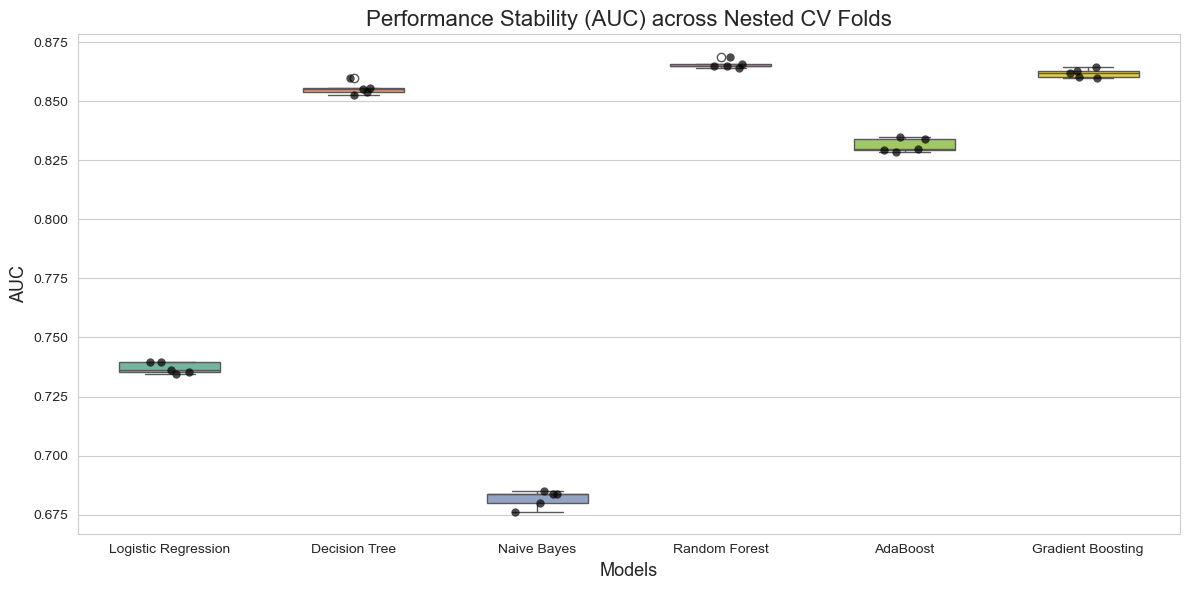

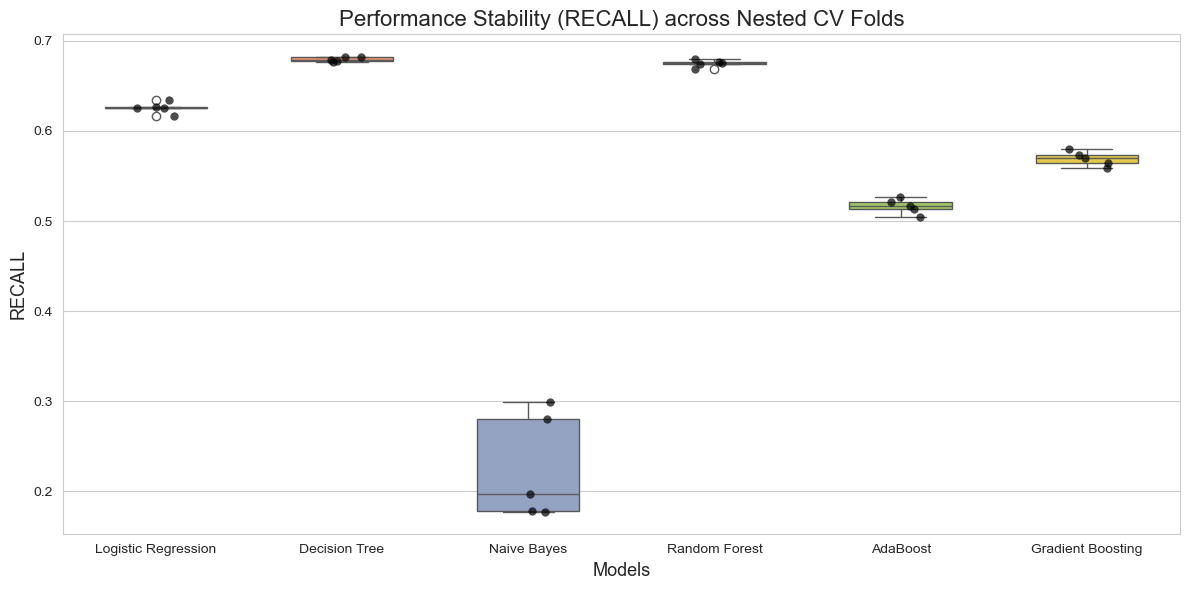

In [12]:
results_dict = {
    "Logistic Regression": lr_results,
    "Decision Tree": dt_results,
    "Naive Bayes": nb_results,
    "Random Forest": rf_results,
    "AdaBoost": ada_results,
    "Gradient Boosting": gb_results
}


def plot_nestedcv_stability(results_dict, metric="auc"):
    dfs = []
    for model_name, res in results_dict.items():
        df = res["folds"].copy()
        if metric not in df.columns:
            raise ValueError(f"Metric '{metric}' not found in folds dataframe.")
        df["model"] = model_name
        dfs.append(df)

    plot_df = pd.concat(dfs, ignore_index=True)

    plt.figure(figsize=(12, 6))
    sns.set_style("whitegrid")

    order = list(results_dict.keys())

    ax = sns.boxplot(
        data=plot_df,
        x="model",
        y=metric,
        hue="model",
        order=order,
        palette="Set2",
        width=0.55,
        showfliers=True,
        legend=False
    )

    sns.stripplot(
        data=plot_df,
        x="model",
        y=metric,
        order=order,
        color="black",
        size=6,
        jitter=0.12,
        alpha=0.7
    )

    ax.set_title(f"Performance Stability ({metric.upper()}) across Nested CV Folds", fontsize=16)
    ax.set_xlabel("Models", fontsize=13)
    ax.set_ylabel(metric.replace("_", " ").upper(), fontsize=13)
    plt.xticks(rotation=0)
    plt.tight_layout()
    plt.show()

plot_nestedcv_stability(results_dict, metric="auc")
plot_nestedcv_stability(results_dict, metric="recall")

The boxplot displays the distribution of the AUC across the 5 outer folds for each model. A narrow box indicates high consistency across sample partitions, meaning the model is insensitive to the specific train/test split—a crucial property for production generalization. Random Forest and Decision Tree present the most compact distributions, whereas Naive Bayes exhibits the highest variability. The presence of outliers in certain folds indicates that specific data partitions are more challenging to learn.



## Final model choice


 Best model: RandFor
   AUC: 0.8656
   Recall: 0.6751
   Balanced Accuracy: 0.7924
   F1: 0.6915
   FNR: 0.3249

 Second best model: GradBoost
   AUC: 0.8619
   Recall: 0.5693
   Balanced Accuracy: 0.7703
   F1: 0.6869
   FNR: 0.4307

 Third best model: DecTree
   AUC: 0.8555
   Recall: 0.6793
   Balanced Accuracy: 0.7846
   F1: 0.6734
   FNR: 0.4307


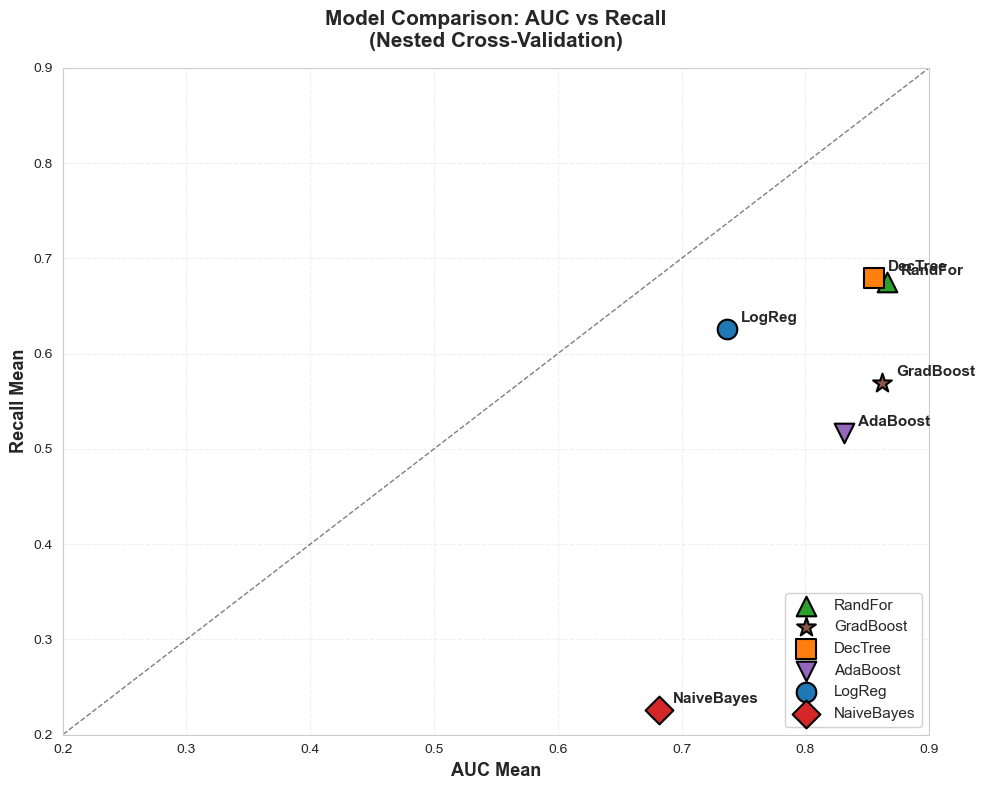

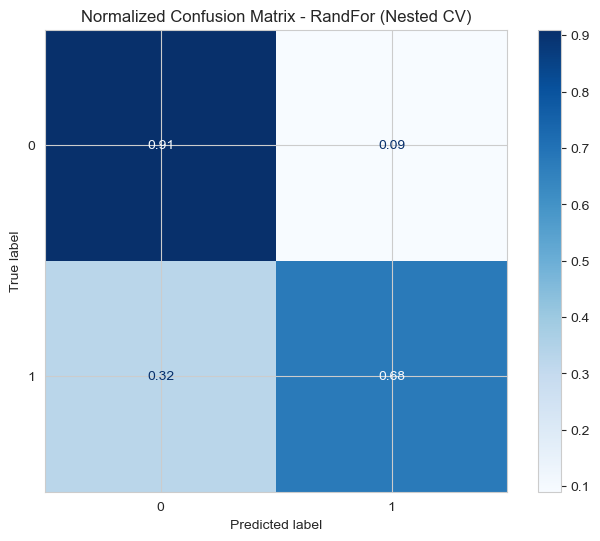

In [15]:
fig, ax = plt.subplots(figsize=(10, 8))

colors = {
    "LogReg": "#1f77b4",      
    "DecTree": "#ff7f0e",     
    "RandFor": "#2ca02c",     
    "NaiveBayes": "#d62728",  
    "AdaBoost": "#9467bd",    
    "GradBoost": "#8c564b"     
}

markers = {
    "LogReg": "o",
    "DecTree": "s",
    "RandFor": "^",
    "NaiveBayes": "D",
    "AdaBoost": "v",
    "GradBoost": "*"
}


for idx, row in results_df.iterrows():
    model = row["model"]
    ax.scatter(
        row["auc_mean"], 
        row["recall_mean"],
        color=colors.get(model, "gray"),
        marker=markers.get(model, "o"),
        s=200,
        label=model,
        edgecolors="black",
        linewidths=1.5
    )
    
    ax.annotate(
        model,
        (row["auc_mean"], row["recall_mean"]),
        textcoords="offset points",
        xytext=(10, 5),
        fontsize=11,
        fontweight="bold"
    )


ax.set_xlabel("AUC Mean", fontsize=13, fontweight="bold")
ax.set_ylabel("Recall Mean", fontsize=13, fontweight="bold")
ax.set_title("Model Comparison: AUC vs Recall\n(Nested Cross-Validation)", fontsize=15, fontweight="bold", pad=15)

ax.grid(True, alpha=0.3, linestyle="--")
ax.legend(loc="lower right", fontsize=11, framealpha=0.9)


ax.set_xlim(0.2, 0.9)
ax.set_ylim(0.2, 0.9)

x_vals = [0, 1.0]
ax.plot(x_vals, x_vals, "k--", alpha=0.5, linewidth=1, label="Reference (recall = bal_acc)")

plt.tight_layout()

best_model = results_df.iloc[0]["model"]
print(f"\n Best model: {best_model}")
print(f"   AUC: {results_df.iloc[0]['auc_mean']:.4f}")
print(f"   Recall: {results_df.iloc[0]['recall_mean']:.4f}")
print(f"   Balanced Accuracy: {results_df.iloc[0]['balanced_accuracy_mean']:.4f}")
print(f"   F1: {results_df.iloc[0]['f1_mean']:.4f}")
print(f"   FNR: {results_df.iloc[0]['fnr_mean']:.4f}")

second_best_model = results_df.iloc[1]["model"]
print(f"\n Second best model: {second_best_model}")
print(f"   AUC: {results_df.iloc[1]['auc_mean']:.4f}")
print(f"   Recall: {results_df.iloc[1]['recall_mean']:.4f}")
print(f"   Balanced Accuracy: {results_df.iloc[1]['balanced_accuracy_mean']:.4f}")
print(f"   F1: {results_df.iloc[1]['f1_mean']:.4f}")
print(f"   FNR: {results_df.iloc[1]['fnr_mean']:.4f}")

Third_best_model = results_df.iloc[2]["model"]
print(f"\n Third best model: {Third_best_model}")
print(f"   AUC: {results_df.iloc[2]['auc_mean']:.4f}")
print(f"   Recall: {results_df.iloc[2]['recall_mean']:.4f}")
print(f"   Balanced Accuracy: {results_df.iloc[2]['balanced_accuracy_mean']:.4f}")
print(f"   F1: {results_df.iloc[2]['f1_mean']:.4f}")
print(f"   FNR: {results_df.iloc[1]['fnr_mean']:.4f}")

plt.show()

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

best_model_name = results_df.iloc[0]["model"]

if best_model_name == "LogReg":
    y_pred = lr_results["oof_pred"]
elif best_model_name == "DecTree":
    y_pred = dt_results["oof_pred"]
elif best_model_name == "RandFor":
    y_pred = rf_results["oof_pred"]
elif best_model_name == "NaiveBayes":
    y_pred = nb_results["oof_pred"]
elif best_model_name == "AdaBoost":
    y_pred = ada_results["oof_pred"]
elif best_model_name == "GradBoost":
    y_pred = gb_results["oof_pred"]

y_true = y

cm = confusion_matrix(y_true, y_pred, normalize="true")

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[0,1])

fig, ax = plt.subplots(figsize=(8, 6))
disp.plot(cmap="Blues", values_format=".2f", ax=ax)
plt.title(f"Normalized Confusion Matrix - {best_model_name} (Nested CV)")
plt.show()



The plot maps each model within the AUC-Recall space, allowing for a visual assessment of the operational trade-off. In banking contexts, recall is prioritized to minimize False Negatives (undetected defaults). The chart enables model selection based on an operational loss function, without reducing the comparison to a single scalar metric.

### Roc plot

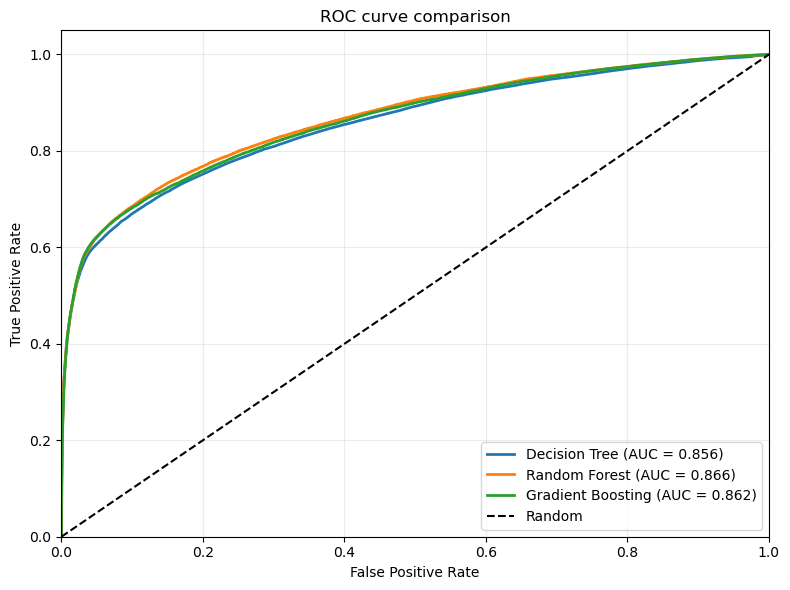

In [149]:
models = {
    "Decision Tree": dt_results,
    "Random Forest": rf_results,
    "Gradient Boosting": gb_results,
}

plt.figure(figsize=(8, 6))

for name, res in models.items():
    fpr, tpr, _ = roc_curve(y, res["oof_proba"])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, lw=2, label=f"{name} (AUC = {roc_auc:.3f})")

plt.plot([0, 1], [0, 1], "k--", lw=1.5, label="Random")
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC curve comparison")
plt.legend(loc="lower right")
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

The ROC curves compare the discriminative capacity of the three top-performing models across all possible decision thresholds. The AUC represents the probability that the model assigns a higher risk score to a randomly chosen positive case (default) than to a negative one. All three curves sit well above the random diagonal, confirming the strong predictive power of the models. 

### Wilcoxon tests

In [89]:
pairs = [
    ("RandFor", "DecTree"),
    ("RandFor", "GradBoost"),
    ("DecTree", "GradBoost")
]

model_map = {
    "RandFor": rf_results,
    "DecTree": dt_results,
    "GradBoost": gb_results
}

rows = []

for m1, m2 in pairs:
    s1 = model_map[m1]["folds"]["auc"].values
    s2 = model_map[m2]["folds"]["auc"].values

    stat, p = wilcoxon(s1, s2, alternative="two-sided", zero_method="wilcox")

    rows.append({
        "model_1": m1,
        "model_2": m2,
        "metric": "auc_macro",
        "wilcoxon_stat": stat,
        "p_value": p,
        "mean_diff": (s1 - s2).mean()
    })

wilcoxon_df = pd.DataFrame(rows)
display(wilcoxon_df)

,model_1,model_2,metric,wilcoxon_stat,p_value,mean_diff
0,RandFor,DecTree,auc_macro,0.0,0.0625,0.010064
1,RandFor,GradBoost,auc_macro,0.0,0.0625,0.003655
2,DecTree,GradBoost,auc_macro,0.0,0.0625,-0.006409


The pairwise Wilcoxon signed-rank test compares the distribution of AUC scores across the outer folds for the three best-performing models. The p-value of 0.0625 for all comparisons exceeds the threshold $\alpha = 0.05$; thus, there is insufficient statistical evidence to claim a significant difference in performance between the two. Given the lack of a significant difference between Random Forest and Decision Tree, the principle of parsimony guides the selection toward the simpler, more interpretable model.

### Normalized Confusion Matrix of chosen model

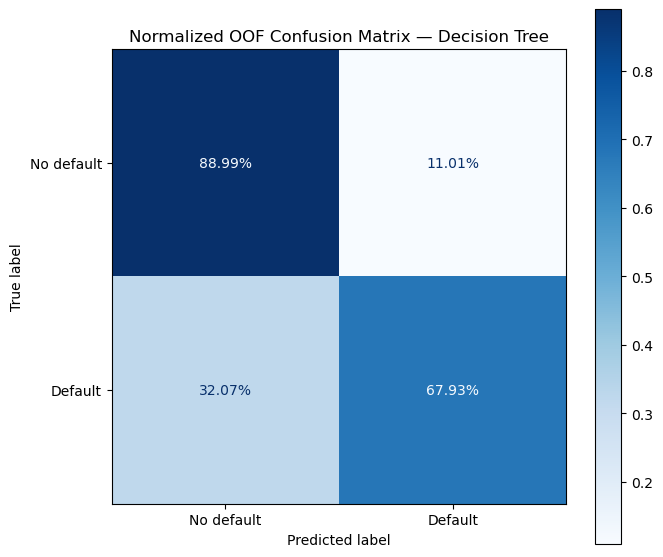

False Negative Rate (missed defaults): 32.1%
False Positive Rate (false alarms):    11.0%


In [17]:
# Final model = Decision Tree (chosen by parsimony, Wilcoxon p=0.0625)
y_true = y
y_pred_dt = dt_results["oof_pred"]

cm = confusion_matrix(y_true, y_pred_dt, normalize="true")
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["No default", "Default"])

fig, ax = plt.subplots(figsize=(7, 6))
disp.plot(cmap="Blues", values_format=".2%", ax=ax, colorbar=True)
ax.set_title("Normalized OOF Confusion Matrix — Decision Tree")
plt.tight_layout()
plt.show()

tn, fp, fn, tp = confusion_matrix(y_true, y_pred_dt).ravel()
print(f"False Negative Rate (missed defaults): {fn/(fn+tp):.1%}")
print(f"False Positive Rate (false alarms):    {fp/(fp+tn):.1%}")

### Saving / Loading

Saving

In [90]:
df.to_parquet("output/df_clean.parquet")
X.to_parquet("output/X.parquet")
y.to_frame("Status").to_parquet("output/y.parquet")

joblib.dump(preprocess, "output/preprocess.joblib")
joblib.dump(best_model, "output/best_model.joblib")
joblib.dump(results, "output/results.joblib")

['output/results.joblib']

Loading

In [6]:
df = pd.read_parquet("output/df_clean.parquet")
X = pd.read_parquet("output/X.parquet")
y = pd.read_parquet("output/y.parquet")["Status"]

preprocess = joblib.load("output/preprocess.joblib")
bestmodel = joblib.load("output/best_model.joblib")
results = joblib.load("output/results.joblib")
final_grid = joblib.load("output/final_dt_model.joblib")
best_model = final_grid.best_estimator_
#print(best_model)

# Final Tuning and Training

In [ ]:
pipeline_final = Pipeline([
    ("preprocess", preprocess),
    ("clf", DecisionTreeClassifier(random_state=SEED))
])

cv_inner = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

random_space = {
    "clf__max_depth": [None] + list(range(2, 31)),
    "clf__min_samples_leaf": list(range(1, 101)),
    "clf__criterion": ["gini", "entropy", "log_loss"],
    "clf__class_weight": [None, "balanced"]
}

random_search = RandomizedSearchCV(
    estimator=pipeline_final,
    param_distributions=random_space,
    n_iter=60,
    scoring="roc_auc",
    cv=cv_inner,
    random_state=SEED,
    n_jobs=1,
    verbose=1,
    refit=True,
    return_train_score=True
)

random_search.fit(X, y)

random_df = pd.DataFrame(random_search.cv_results_).copy()
random_df = random_df[["params", "mean_test_score", "std_test_score", "rank_test_score"]].rename(
    columns={"mean_test_score": "mean_auc", "std_test_score": "std_auc"}
)
random_df = pd.concat([random_df.drop(columns=["params"]), pd.json_normalize(random_df["params"])], axis=1)
random_df = random_df.sort_values("mean_auc", ascending=False).reset_index(drop=True)

best3 = random_df.head(3)

md_vals = []
msl_vals = []
crit_vals = []
cw_vals = []

for _, r in best3.iterrows():
    d = r["clf__max_depth"]
    if pd.isna(d) or d == "None":
        md_vals.append(None)
    else:
        d = int(d)
        md_vals.extend([max(1, d - 2), d, d + 2])
    m = int(r["clf__min_samples_leaf"])
    msl_vals.extend([max(1, m - 10), m, m + 10])
    crit_vals.append(r["clf__criterion"])
    cw_vals.append(r["clf__class_weight"])

local_param_grid = {
    "clf__max_depth": [None] if any(v is None for v in md_vals) else sorted(set(md_vals)),
    "clf__min_samples_leaf": sorted(set(msl_vals)),
    "clf__criterion": sorted(set(crit_vals)),
    "clf__class_weight": sorted(set(cw_vals), key=lambda x: str(x))
}

local_grid = GridSearchCV(
    estimator=pipeline_final,
    param_grid=local_param_grid,
    scoring="roc_auc",
    cv=cv_inner,
    n_jobs=1,
    verbose=1,
    refit=True,
    return_train_score=True
)

local_grid.fit(X, y)

local_df = pd.DataFrame(local_grid.cv_results_).copy()
local_df = local_df[["params", "mean_test_score", "std_test_score", "rank_test_score"]].rename(
    columns={"mean_test_score": "mean_auc", "std_test_score": "std_auc"}
)
local_df = pd.concat([local_df.drop(columns=["params"]), pd.json_normalize(local_df["params"])], axis=1)
local_df = local_df.sort_values("mean_auc", ascending=False).reset_index(drop=True)

print("Best random params:")
print(random_search.best_params_)
print("Best random AUC:", random_search.best_score_)
print()
print("Best local params:")
print(local_grid.best_params_)
print("Best local AUC:", local_grid.best_score_)
print()
display(random_df.head(10))
display(local_df.head(10))

Fitting 5 folds for each of 60 candidates, totalling 300 fits
Fitting 5 folds for each of 216 candidates, totalling 1080 fits
Best random params:
{'clf__min_samples_leaf': 24, 'clf__max_depth': 11, 'clf__criterion': 'log_loss', 'clf__class_weight': 'balanced'}
Best random AUC: 0.8557301675620073

Best local params:
{'clf__class_weight': None, 'clf__criterion': 'entropy', 'clf__max_depth': 13, 'clf__min_samples_leaf': 88}
Best local AUC: 0.8560005396866213



,mean_auc,std_auc,rank_test_score,clf__min_samples_leaf,clf__max_depth,clf__criterion,clf__class_weight
0,0.855730,0.002910,1,24,11.0,log_loss,balanced
1,0.855295,0.002422,2,98,13.0,entropy,None
2,0.855276,0.002965,3,68,13.0,gini,None
3,0.854576,0.003752,4,44,10.0,entropy,None
4,0.854576,0.001632,5,86,16.0,gini,None
5,0.854420,0.002737,6,22,11.0,gini,None
6,0.854327,0.003612,7,54,13.0,gini,balanced
7,0.854246,0.001383,8,86,17.0,gini,None
8,0.854081,0.003502,9,34,13.0,gini,balanced
9,0.853930,0.003147,10,91,10.0,entropy,balanced


,mean_auc,std_auc,rank_test_score,clf__class_weight,clf__criterion,clf__max_depth,clf__min_samples_leaf
0,0.856001,0.002168,1,None,log_loss,13,88
1,0.856001,0.002168,1,None,entropy,13,88
2,0.855797,0.003590,3,None,log_loss,11,58
3,0.855797,0.003590,3,None,entropy,11,58
4,0.855730,0.002910,5,balanced,entropy,11,24
5,0.855730,0.002910,5,balanced,log_loss,11,24
6,0.855652,0.002885,7,None,entropy,13,58
7,0.855652,0.002885,7,None,log_loss,13,58
8,0.855634,0.002735,9,balanced,log_loss,11,34
9,0.855634,0.002735,9,balanced,entropy,11,34


In [91]:
joblib.dump(local_grid, "output/final_dt_model.joblib")
best_hparams = local_grid.best_params_
best_model = local_grid.best_estimator_

print(best_hparams)
#print(best_model)

{'clf__class_weight': None, 'clf__criterion': 'entropy', 'clf__max_depth': 13, 'clf__min_samples_leaf': 88}


In [ ]:
results_df = pd.DataFrame(local_grid.cv_results_).copy()

cols = [
    "params",
    "mean_test_score",
    "std_test_score",
    "rank_test_score",
    "mean_fit_time",
    "std_fit_time",
]
for c in cols:
    if c not in results_df.columns:
        print(f"Colonna mancante: {c}")

results_df = results_df[cols].rename(columns={
    "mean_test_score": "mean_auc",
    "std_test_score": "std_auc",
})

params_expanded = pd.json_normalize(results_df["params"])
results_df = pd.concat([results_df.drop(columns=["params"]), params_expanded], axis=1)

results_df = results_df.sort_values("mean_auc", ascending=False).reset_index(drop=True)

results_df.to_csv("output/dt_final_grid_results.csv", index=False)

display(results_df.head(10))

,mean_auc,std_auc,rank_test_score,mean_fit_time,std_fit_time,clf__class_weight,clf__criterion,clf__max_depth,clf__min_samples_leaf
0,0.856001,0.002168,1,1.442726,0.006755,None,log_loss,13,88
1,0.856001,0.002168,1,1.500291,0.018916,None,entropy,13,88
2,0.855797,0.003590,3,1.357427,0.053737,None,log_loss,11,58
3,0.855797,0.003590,3,1.296617,0.012799,None,entropy,11,58
4,0.855730,0.002910,5,1.370680,0.012136,balanced,entropy,11,24
5,0.855730,0.002910,5,1.375358,0.007678,balanced,log_loss,11,24
6,0.855652,0.002885,7,1.511628,0.029485,None,entropy,13,58
7,0.855652,0.002885,7,1.485046,0.003905,None,log_loss,13,58
8,0.855634,0.002735,9,1.418084,0.043989,balanced,log_loss,11,34
9,0.855634,0.002735,9,1.371872,0.018035,balanced,entropy,11,34


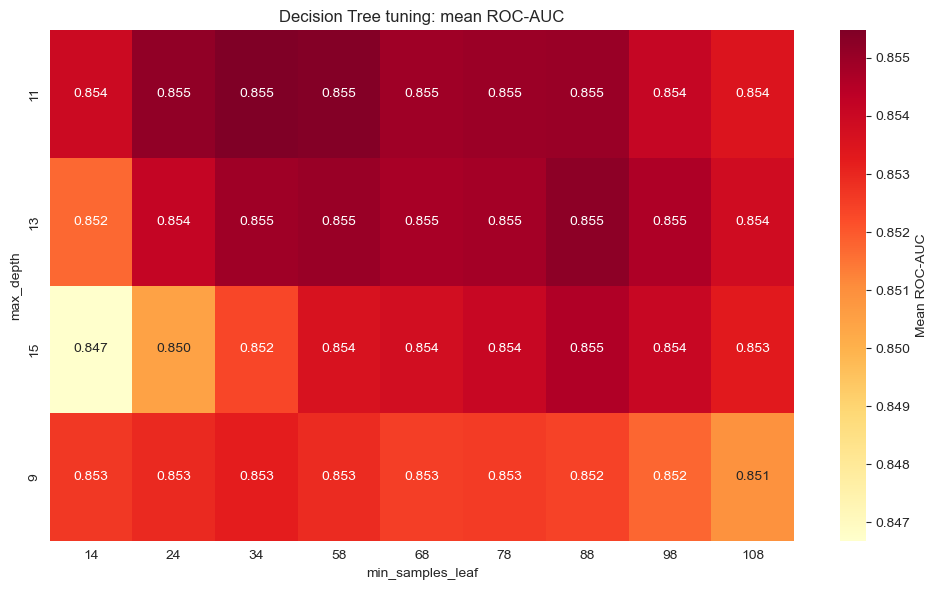

In [ ]:
plot_df = results_df.copy()
plot_df["clf__max_depth"] = plot_df["clf__max_depth"].astype(str)
plot_df["clf__min_samples_leaf"] = plot_df["clf__min_samples_leaf"].astype(int)

pivot = plot_df.pivot_table(
    index="clf__max_depth",
    columns="clf__min_samples_leaf",
    values="mean_auc",
    aggfunc="mean"
)

plt.figure(figsize=(10, 6))
sns.heatmap(pivot, annot=True, fmt=".3f", cmap="YlOrRd", cbar_kws={"label": "Mean ROC-AUC"})
plt.title("Decision Tree tuning: mean ROC-AUC")
plt.xlabel("min_samples_leaf")
plt.ylabel("max_depth")
plt.tight_layout()
plt.savefig("output/dt_final_grid_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()

The heatmap visualizes the mean AUC of the Decision Tree across the variations of its two most influential hyperparameters: `max_depth` (maximum tree depth) and `min_samples_leaf` (minimum number of samples required at a leaf node). High values of `min_samples_leaf` combined with restricted `max_depth` tend to produce more regularized trees, thereby reducing overfitting. The optimal cell identifies the configuration that maximizes AUC during internal cross-validation, while also offering insight into the smoothness of the hyperparameter landscape; a flat region surrounding the maximum indicates hyperparameter robustness.

# XAI

In [153]:
final_model = best_model
preprocessor = final_model.named_steps["preprocess"]

X_transformed = preprocessor.transform(X)

if sp.issparse(X_transformed):
    X_transformed = X_transformed.toarray()

feature_names = preprocessor.get_feature_names_out()
feature_names = [re.sub(r'^[^_]+__', '', col) for col in feature_names]
X_transformed_df = pd.DataFrame(X_transformed, columns=feature_names)
clean_names = list(X_transformed_df.columns)


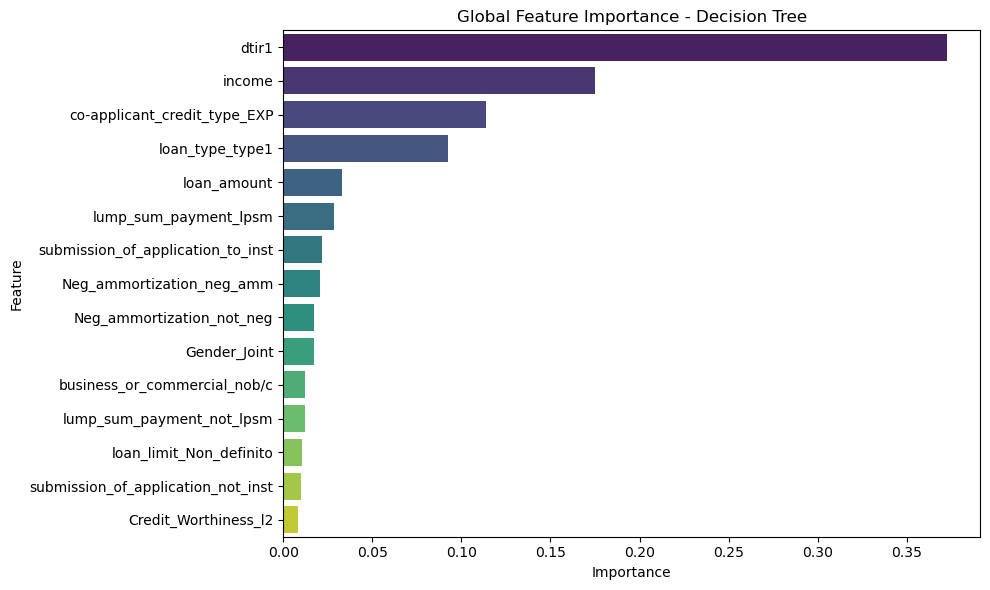

In [154]:
clf = final_model.named_steps["clf"]
importances = clf.feature_importances_

clean_names = [
    name.replace("num__", "").replace("cat__", "")
    for name in feature_names
]

df_importance = pd.DataFrame({
    'Feature': clean_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=df_importance.head(15), hue="Feature", palette="viridis", legend=False)
plt.title('Global Feature Importance - Decision Tree')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()


The chart illustrates the top 15 features according to the Decision Tree's native Gini importance, which reflects the average contribution of each variable to the reduction of node impurity during splits. `income` and `dtir1` (debt-to-income ratio) typically emerge as the strongest predictors, aligning with established credit risk literature. Categorical features appear in their one-hot encoded form, meaning their overall relevance is distributed across multiple columns.

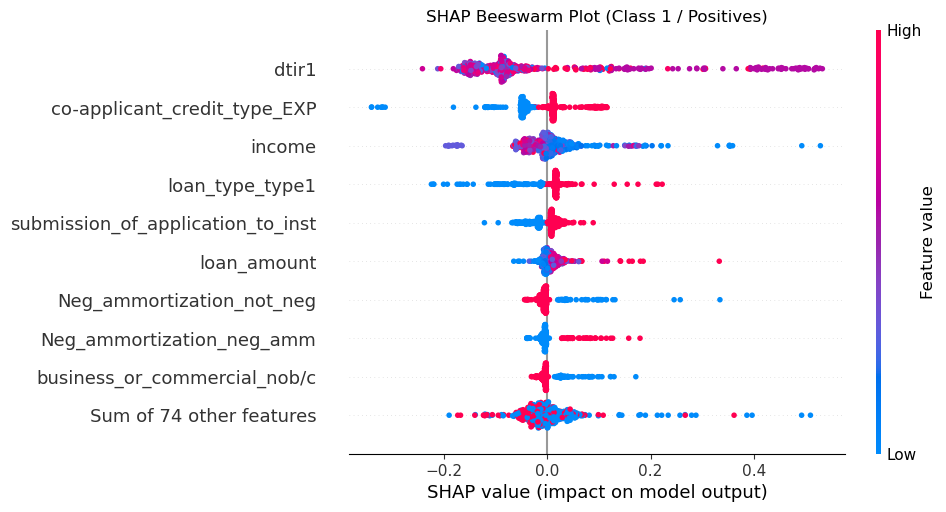

In [155]:
clf = best_model.named_steps["clf"]

X_transformed_df.columns = [
    re.sub(r'^[^_]+__', '', col) for col in X_transformed_df.columns
]

X_subset = X_transformed_df.head(500)
explainer = shap.TreeExplainer(clf)
shap_values_obj = explainer(X_subset)

if len(shap_values_obj.shape) == 3:
    shap_values_class1 = shap_values_obj[:, :, 1]
else:
    shap_values_class1 = shap_values_obj

plt.figure(figsize=(10, 6))
plt.title("SHAP Beeswarm Plot (Class 1 / Positives)")
shap.plots.beeswarm(shap_values_class1)
plt.show()


Predicted label: 1
Ground-truth label: 1


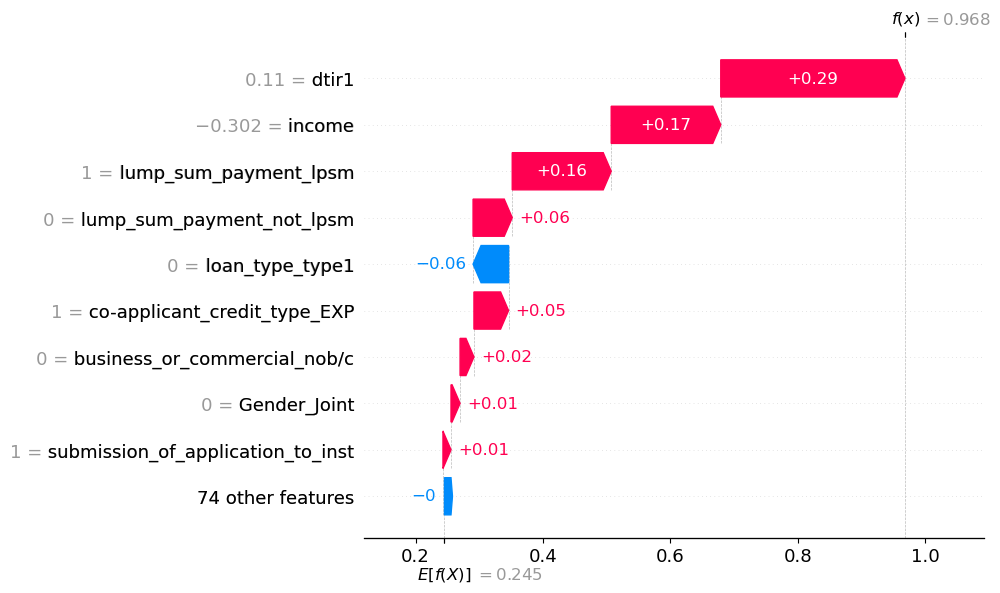

In [156]:
import numpy as np
import matplotlib.pyplot as plt

X_subset_array = X_subset.to_numpy()
predicted_labels = clf.predict(X_subset_array)

if "y_subset" in globals() and globals()["y_subset"] is not None:
    true_labels = globals()["y_subset"].iloc[:len(X_subset)].reset_index(drop=True)
else:
    true_labels = y.iloc[:min(len(X_subset), len(y))].reset_index(drop=True)

y_subset = true_labels

match_idx = np.where((predicted_labels == 1) & (true_labels == 1))[0]

if len(match_idx) > 0:
    sample_idx = int(match_idx[0])
else:
    sample_idx = 0
    print("No correctly classified default cases found in this subset; showing the first sample instead.")

print(f"Predicted label: {predicted_labels[sample_idx]}")
print(f"Ground-truth label: {true_labels.iloc[sample_idx] if hasattr(true_labels, 'iloc') else true_labels[sample_idx]}")

plt.figure(figsize=(10, 4))
shap.plots.waterfall(shap_values_class1[sample_idx])
plt.show()


## Error Analysis: what drives False Negatives and False Positives

We recompute SHAP on a stratifie sample (balanced across classes) so that it
contains enough misclassified defaults (FN) and false alarms (FP) to study.
SHAP here explains the final deployed model (Decision Tree trained on full data).

In [157]:
# Final model components
clf = best_model.named_steps["clf"]
feature_names = list(X_transformed_df.columns)

# --- Build a stratified sample (positional alignment with y) ---
rng = np.random.RandomState(SEED)
y_arr = y.to_numpy()
n_per_class = 2500   # defaults are the minority: oversample them for the analysis

pos_idx = np.where(y_arr == 1)[0]
neg_idx = np.where(y_arr == 0)[0]
n_pos = min(n_per_class, len(pos_idx))
n_neg = min(n_per_class, len(neg_idx))

sample_pos = np.concatenate([
    rng.choice(pos_idx, size=n_pos, replace=False),
    rng.choice(neg_idx, size=n_neg, replace=False),
])
rng.shuffle(sample_pos)

# --- Build a NumPy array for the model and a DataFrame for SHAP labels ---
X_an_raw = X_transformed_df.iloc[sample_pos].reset_index(drop=True)
X_an = X_an_raw.values  # array for model prediction
X_an_shap = X_an_raw    # DataFrame so SHAP can use real feature names

y_an = y_arr[sample_pos]

# --- Predictions of the FINAL model on the analysis sample ---
THRESHOLD = 0.5
proba_an = clf.predict_proba(X_an)[:, 1]
pred_an  = (proba_an >= THRESHOLD).astype(int)

# --- SHAP values (class 1 = Default) ---
explainer = shap.TreeExplainer(clf)
sv = explainer(X_an_shap)
sv_class1 = sv[:, :, 1] if sv.values.ndim == 3 else sv
df_shap = pd.DataFrame(sv_class1.values, columns=feature_names)

# --- Confusion-matrix masks (positional numpy booleans) ---
mask_tp = (y_an == 1) & (pred_an == 1)   # caught default
mask_fn = (y_an == 1) & (pred_an == 0)   # MISSED default
mask_tn = (y_an == 0) & (pred_an == 0)   # correct no-default
mask_fp = (y_an == 0) & (pred_an == 1)   # FALSE alarm

print(f"Analysis sample: {len(y_an)} rows")
print(f"TP={mask_tp.sum()}  FN={mask_fn.sum()}  TN={mask_tn.sum()}  FP={mask_fp.sum()}")

Analysis sample: 5000 rows
TP=1466  FN=1034  TN=2419  FP=81


### What drives a FALSE NEGATIVE (a missed default)?

A FN is a true default the model scored as low-risk. We compare the mean SHAP of
FN cases against TP cases (both are *real defaults*): the difference reveals which
features wrongly pushed the missed ones toward "no default".

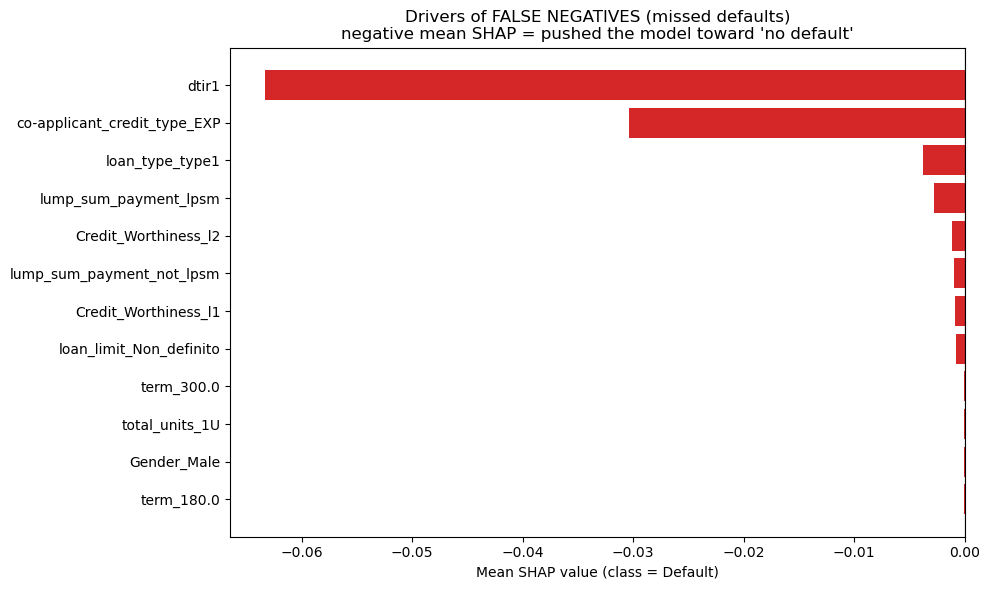

,FN,TP,FN_minus_TP
dtir1,-0.0633,0.3500,-0.4133
co-applicant_credit_type_EXP,-0.0303,0.0624,-0.0927
loan_type_type1,-0.0037,0.0286,-0.0323
lump_sum_payment_lpsm,-0.0028,0.0246,-0.0274
Credit_Worthiness_l2,-0.0011,0.0049,-0.0060
lump_sum_payment_not_lpsm,-0.0010,0.0085,-0.0094
Credit_Worthiness_l1,-0.0008,0.0027,-0.0036
loan_limit_Non_definito,-0.0008,0.0046,-0.0054
term_300.0,-0.0000,-0.0001,0.0001
total_units_1U,-0.0000,0.0000,-0.0000


In [158]:
top_n = 12

mean_shap_fn = df_shap[mask_fn].mean()
mean_shap_tp = df_shap[mask_tp].mean()

comp_fn = pd.DataFrame({"FN": mean_shap_fn, "TP": mean_shap_tp})
comp_fn["FN_minus_TP"] = comp_fn["FN"] - comp_fn["TP"]

# Most negative SHAP in FN = strongest pull toward "no default"
order = comp_fn["FN"].sort_values().index[:top_n][::-1]

plt.figure(figsize=(10, 6))
plt.barh(order, comp_fn.loc[order, "FN"], color="#d62728")
plt.axvline(0, color="black", lw=0.8)
plt.title("Drivers of FALSE NEGATIVES (missed defaults)\n"
          "negative mean SHAP = pushed the model toward 'no default'")
plt.xlabel("Mean SHAP value (class = Default)")
plt.tight_layout()
plt.show()

display(comp_fn.reindex(comp_fn["FN"].sort_values().index).head(top_n).round(4))

### What drives a FALSE POSITIVE (a false alarm)?

A FP is a true non-default the model flagged as risky. We compare FP vs TN (both
are *real non-defaults*): the difference shows which features wrongly pushed the
false alarms toward "default".

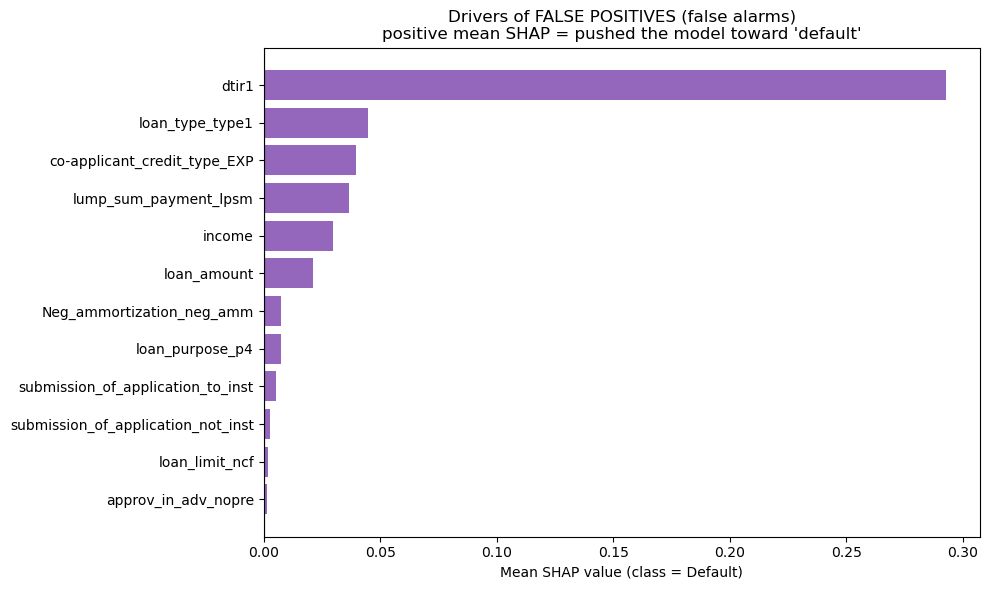

,FP,TN,FP_minus_TN
dtir1,0.2928,-0.0749,0.3677
loan_type_type1,0.0446,-0.0022,0.0468
co-applicant_credit_type_EXP,0.0395,-0.0282,0.0677
lump_sum_payment_lpsm,0.0367,-0.0047,0.0414
income,0.0296,-0.0134,0.0430
loan_amount,0.0210,0.0071,0.0138
Neg_ammortization_neg_amm,0.0074,-0.0018,0.0092
loan_purpose_p4,0.0073,0.0024,0.0049
submission_of_application_to_inst,0.0055,-0.0032,0.0087
submission_of_application_not_inst,0.0027,-0.0028,0.0055


In [159]:
mean_shap_fp = df_shap[mask_fp].mean()
mean_shap_tn = df_shap[mask_tn].mean()

comp_fp = pd.DataFrame({"FP": mean_shap_fp, "TN": mean_shap_tn})
comp_fp["FP_minus_TN"] = comp_fp["FP"] - comp_fp["TN"]

# Most positive SHAP in FP = strongest pull toward "default"
order = comp_fp["FP"].sort_values(ascending=False).index[:top_n][::-1]

plt.figure(figsize=(10, 6))
plt.barh(order, comp_fp.loc[order, "FP"], color="#9467bd")
plt.axvline(0, color="black", lw=0.8)
plt.title("Drivers of FALSE POSITIVES (false alarms)\n"
          "positive mean SHAP = pushed the model toward 'default'")
plt.xlabel("Mean SHAP value (class = Default)")
plt.tight_layout()
plt.show()

display(comp_fp.reindex(comp_fp["FP"].sort_values(ascending=False).index).head(top_n).round(4))

Visual comparison on all four TP/TN/FP/FN

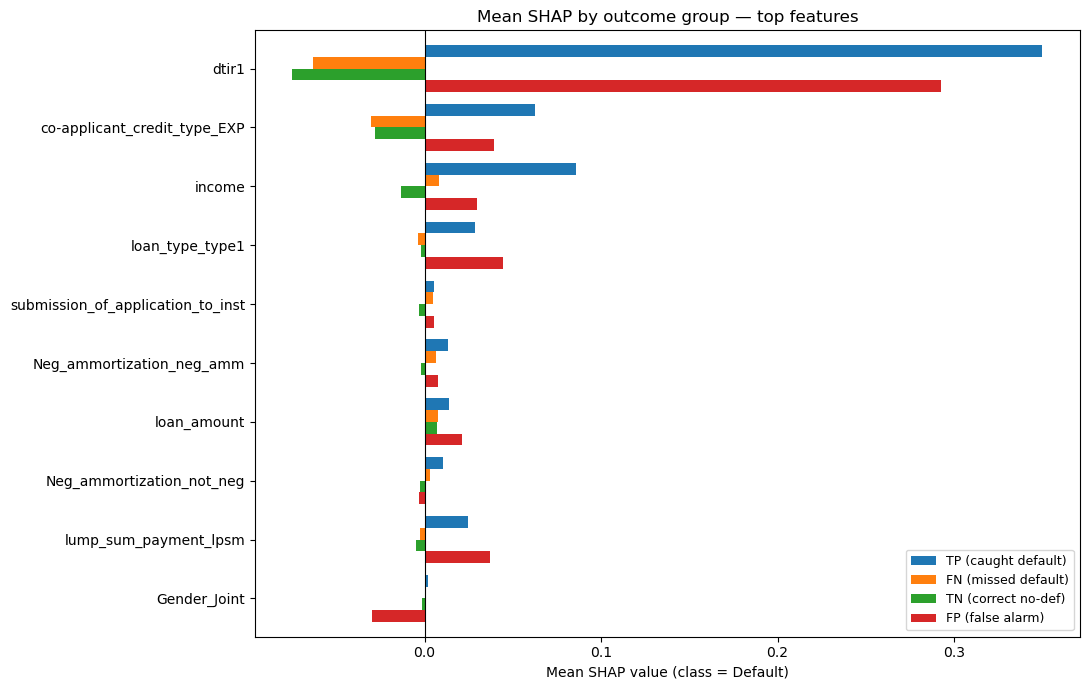

In [160]:
top_global = df_shap.abs().mean().sort_values(ascending=False).head(10).index.tolist()

group_means = pd.DataFrame({
    "TP (caught default)":  df_shap[mask_tp][top_global].mean(),
    "FN (missed default)":  df_shap[mask_fn][top_global].mean(),
    "TN (correct no-def)":  df_shap[mask_tn][top_global].mean(),
    "FP (false alarm)":     df_shap[mask_fp][top_global].mean(),
})

group_means.plot(kind="barh", figsize=(11, 7), width=0.8)
plt.axvline(0, color="black", lw=0.8)
plt.title("Mean SHAP by outcome group — top features")
plt.xlabel("Mean SHAP value (class = Default)")
plt.gca().invert_yaxis()
plt.legend(loc="lower right", fontsize=9)
plt.tight_layout()
plt.show()

representatives cases: FN and FP waterfalls

Representative FALSE NEGATIVE — pred. default prob = 0.181 (true = default)


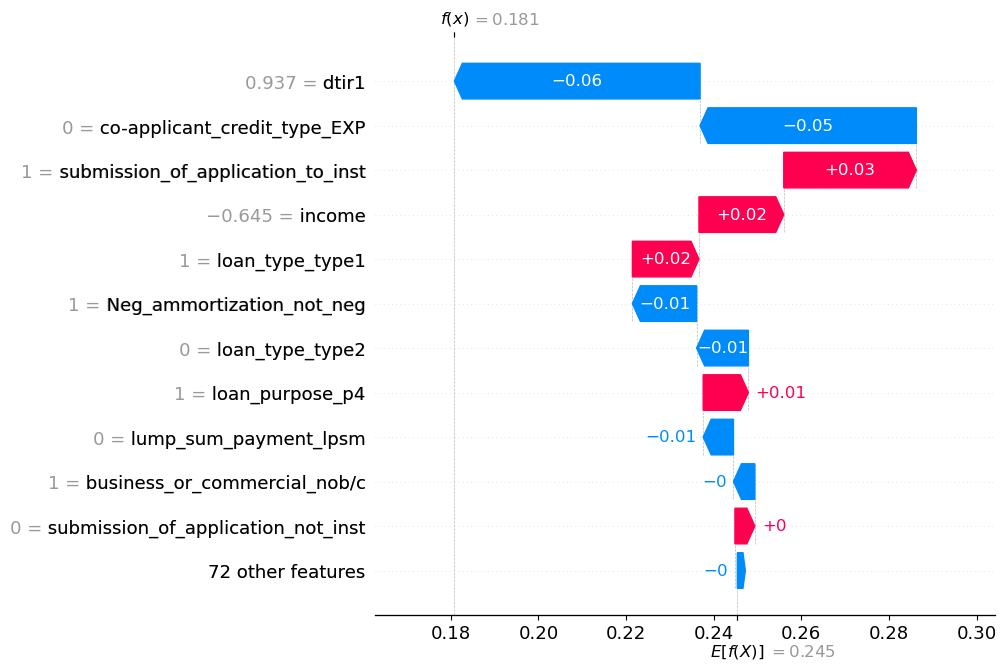

Representative FALSE POSITIVE — pred. default prob = 0.708 (true = no default)


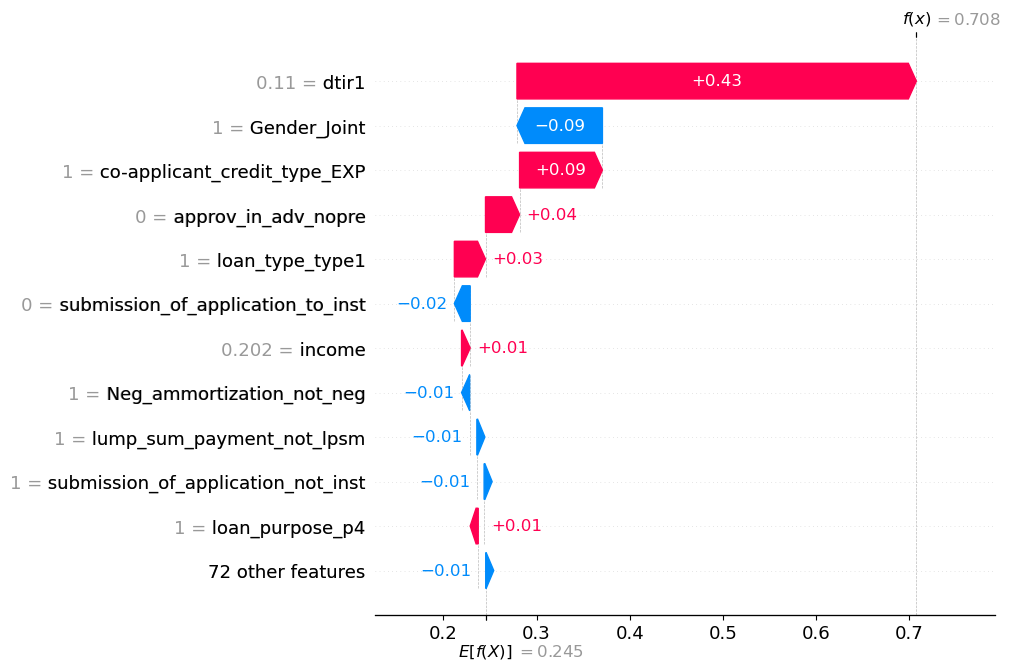

In [161]:
def representative_pos(mask, proba):
    """Return the positional index of the case closest to the group's median proba."""
    idxs = np.where(mask)[0]
    if len(idxs) == 0:
        return None
    target = np.median(proba[idxs])
    return idxs[np.argmin(np.abs(proba[idxs] - target))]

pos_fn = representative_pos(mask_fn, proba_an)
pos_fp = representative_pos(mask_fp, proba_an)

if pos_fn is not None:
    print(f"Representative FALSE NEGATIVE — pred. default prob = {proba_an[pos_fn]:.3f} (true = default)")
    shap.plots.waterfall(sv_class1[pos_fn], max_display=12)

if pos_fp is not None:
    print(f"Representative FALSE POSITIVE — pred. default prob = {proba_an[pos_fp]:.3f} (true = no default)")
    shap.plots.waterfall(sv_class1[pos_fp], max_display=12)